In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/PaddleDet-Models

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/.shortcut-targets-by-id/17LXx-YpP2lamkZUgiY1A62xV8O46AQcz/PaddleDet-Models


In [ ]:
!python --version

Python 3.12.13


In [ ]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/markerpensseg/train/")
count_images("datasets/markerpensseg/valid")

Total images: 225
Total images: 30


In [ ]:
# Check train annotations
with open("datasets/markerpensseg/train/_annotations.coco.json") as f:
    train_data = json.load(f)
    print(f"Train images: {len(train_data['images'])}")
    print(f"Train annotations: {len(train_data['annotations'])}")
    print(f"Categories: {train_data['categories']}")

# Check validation
with open("datasets/markerpensseg/valid/_annotations.coco.json") as f:
    valid_data = json.load(f)
    print(f"\nValid images: {len(valid_data['images'])}")
    print(f"Valid annotations: {len(valid_data['annotations'])}")

Train images: 225
Train annotations: 450
Categories: [{'id': 0, 'name': 'caps-7o2C', 'supercategory': 'none'}, {'id': 1, 'name': 'CAP', 'supercategory': 'caps-7o2C'}]

Valid images: 30
Valid annotations: 60


In [2]:
!git clone https://github.com/PaddlePaddle/PaddleDetection.git
%cd PaddleDetection

fatal: destination path 'PaddleDetection' already exists and is not an empty directory.
/content/gdrive/.shortcut-targets-by-id/17LXx-YpP2lamkZUgiY1A62xV8O46AQcz/PaddleDet-Models/PaddleDetection


In [3]:
!pip install paddlepaddle-gpu pyclipper attrdict gdown -qqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 758.9/758.9 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 69.1 MB/s eta 0:00:00


In [ ]:
# Force the "bridge" version of NumPy that works for both Python 3.12 and Paddle
!pip install numpy==1.26.4 --force-reinstall

# Re-install OpenCV without dependencies to stop it from fighting with NumPy
!pip install opencv-python-headless --no-deps --force-reinstall

In [4]:
!pip install -q -e .

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 443.5/443.5 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.5/60.5 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 130.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.0/417.0 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.0/244.0 kB 27.3 MB/s eta 0:00:00


In [ ]:
!python -c "import paddle; print(paddle.__version__); print(paddle.device.get_device()); import ppdet; print(ppdet.__version__)"

2.6.2
gpu:0
[05/22 16:05:54] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
0.0.0


In [5]:
!python ppdet/modeling/tests/test_architectures.py

[05/22 17:46:54] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0522 17:47:07.519145  3439 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0522 17:47:07.542865  3439 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
.......
----------------------------------------------------------------------
Ran 7 tests in 12.602s

OK


In [6]:
import json
import os

os.makedirs('dataset/coco/annotations', exist_ok=True)

COCO_CLASSES = ('person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
                'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
                'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
                'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
                'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
                'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat',
                'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
                'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
                'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot',
                'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
                'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop',
                'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven',
                'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
                'scissors', 'teddy bear', 'hair drier', 'toothbrush')

categories = []
for i, name in enumerate(COCO_CLASSES):
    categories.append({"id": i, "name": name, "supercategory": "none"})

dummy_data = {
    "images": [],
    "annotations": [],
    "categories": categories
}

with open('dataset/coco/annotations/instances_val2017.json', 'w') as f:
    json.dump(dummy_data, f)

print("Better dummy JSON created! Labels will now show real names.")

Better dummy JSON created! Labels will now show real names.


In [ ]:
!python tools/infer.py \
-c configs/queryinst/queryinst_r50_fpn_1x_pro100_coco.yml \
-o use_gpu=True \
weights=https://bj.bcebos.com/v1/paddledet/models/queryinst_r50_fpn_1x_pro100_coco.pdparams \
--infer_img=/content/gdrive/MyDrive/PaddleDet-Models/datasets/panoptic-tests/birds.png

[05/22 16:09:32] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0522 16:09:38.193534  4896 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0522 16:09:38.194655  4896 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[05/22 16:09:38] ppdet.utils.download INFO: Downloading queryinst_r50_fpn_1x_pro100_coco.pdparams from https://bj.bcebos.com/v1/paddledet/models/queryinst_r50_fpn_1x_pro100_coco.pdparams
100% 674898/674898 [00:14<00:00, 45884.99KB/s]
[05/22 16:09:58] ppdet.utils.checkpoint INFO: Finish loading model weights: /root/.cache/paddle/weights/queryinst_r50_fpn_1x_pro100_coco.pdparams
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
100% 1/1 [00:04<00:00,  4.60s/it]
[05/22 16:10:09] ppdet.engine INFO: Detection bbox results save in output/birds.png


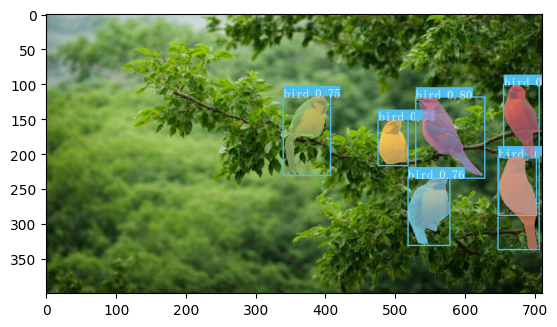

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('output/birds.png')

plt.figure("Image")
plt.imshow(img)
plt.show()

In [ ]:
!python tools/infer.py \
-c configs/queryinst/queryinst_r50_fpn_1x_pro100_coco.yml \
-o use_gpu=True \
weights=https://bj.bcebos.com/v1/paddledet/models/queryinst_r50_fpn_1x_pro100_coco.pdparams \
--infer_dir=/content/gdrive/MyDrive/PaddleDet-Models/datasets/panoptic-tests/ \
--output_dir=output/infer_images_queryinst/ \
--draw_threshold=0.5 \
--save_results=True

[05/22 16:26:20] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0522 16:26:21.005107  9264 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0522 16:26:21.006155  9264 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[05/22 16:26:23] ppdet.utils.checkpoint INFO: Finish loading model weights: /root/.cache/paddle/weights/queryinst_r50_fpn_1x_pro100_coco.pdparams
[05/22 16:26:23] train INFO: Found 18 inference images in total.
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
100% 18/18 [00:19<00:00,  1.07s/it]
[05/22 16:26:43] ppdet.metrics.metrics INFO: The bbox result is saved to bbox.json.
[05/22 16:26:43] ppdet.metrics.metrics INFO: The bbox result is saved to output/infer_images_que

In [9]:
!ls configs/queryinst/

_base_		       queryinst_r50_fpn_1x_pro100_coco.yml	     README.md
queryinst_markers.yml  queryinst_r50_fpn_ms_crop_3x_pro300_coco.yml


In [10]:
225/5

45.0

In [38]:
custom_cfg = """
metric: COCO
num_classes: 2

TrainDataset:
  name: COCODataSet
  image_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/train/
  anno_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/train/_annotations.coco.json
  dataset_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/
  data_fields: ['image', 'gt_bbox', 'gt_class', 'gt_poly', 'is_crowd']

EvalDataset:
  name: COCODataSet
  image_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/
  anno_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/_annotations.coco.json
  dataset_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/

TestDataset:
  name: ImageFolder
  anno_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/_annotations.coco.json
  dataset_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/

worker_num: 6
TrainReader:
  sample_transforms:
  - Decode: {}
  - Poly2Mask: {del_poly: True}
  - Resize: {interp: 1, target_size: [800, 1333], keep_ratio: True}
  - RandomFlip: {prob: 0.5}
  - NormalizeImage: {is_scale: true, mean: [0.485,0.456,0.406], std: [0.229, 0.224,0.225]}
  - Permute: {}
  batch_transforms:
  - PadBatch: {pad_to_stride: 32}
  - Gt2SparseTarget: {}
  batch_size: 5
  shuffle: true
  drop_last: true
  collate_batch: false
  use_shared_memory: true

EvalReader:
  sample_transforms:
  - Decode: {}
  - Resize: {interp: 1, target_size: [800, 1333], keep_ratio: True}
  - NormalizeImage: {is_scale: true, mean: [0.485,0.456,0.406], std: [0.229, 0.224,0.225]}
  - Permute: {}
  batch_transforms:
  - PadBatch: {pad_to_stride: 32}
  - Gt2SparseTarget: {}
  batch_size: 1
  shuffle: false
  drop_last: false

TestReader:
  sample_transforms:
  - Decode: {}
  - Resize: {interp: 1, target_size: [800, 1333], keep_ratio: True}
  - NormalizeImage: {is_scale: true, mean: [0.485,0.456,0.406], std: [0.229, 0.224,0.225]}
  - Permute: {}
  batch_transforms:
  - PadBatch: {pad_to_stride: 32}
  - Gt2SparseTarget: {}
  batch_size: 1
  shuffle: false

num_proposals: &num_proposals 100
proposal_embedding_dim: &proposal_embedding_dim 256
bbox_resolution: &bbox_resolution 7
mask_resolution: &mask_resolution 14

architecture: QueryInst
pretrain_weights: https://bj.bcebos.com/v1/paddledet/models/queryinst_r50_fpn_1x_pro100_coco.pdparams

QueryInst:
  backbone: ResNet
  neck: FPN
  rpn_head: EmbeddingRPNHead
  roi_head: SparseRoIHead
  post_process: SparsePostProcess

ResNet:
  depth: 50
  norm_type: bn
  freeze_at: 0
  return_idx: [ 0, 1, 2, 3 ]
  num_stages: 4
  lr_mult_list: [ 0.1, 0.1, 0.1, 0.1 ]

FPN:
  out_channel: *proposal_embedding_dim
  extra_stage: 0

EmbeddingRPNHead:
  num_proposals: *num_proposals

SparseRoIHead:
  num_stages: 6
  bbox_roi_extractor:
    resolution: *bbox_resolution
    sampling_ratio: 2
    aligned: True
  mask_roi_extractor:
    resolution: *mask_resolution
    sampling_ratio: 2
    aligned: True
  bbox_head: DIIHead
  mask_head: DynamicMaskHead
  loss_func: QueryInstLoss

DIIHead:
  feedforward_channels: 2048
  dynamic_feature_channels: 64
  roi_resolution: *bbox_resolution
  num_attn_heads: 8
  dropout: 0.0
  num_ffn_fcs: 2
  num_cls_fcs: 1
  num_reg_fcs: 3

DynamicMaskHead:
  dynamic_feature_channels: 64
  roi_resolution: *mask_resolution
  num_convs: 4
  conv_kernel_size: 3
  conv_channels: 256
  upsample_method: 'deconv'
  upsample_scale_factor: 2

QueryInstLoss:
  focal_loss_alpha: 0.25
  focal_loss_gamma: 2.0
  class_weight: 2.0
  l1_weight: 5.0
  giou_weight: 2.0
  mask_weight: 8.0

SparsePostProcess:
  num_proposals: *num_proposals
  binary_thresh: 0.5

use_gpu: true
use_xpu: false
log_iter: 5
save_dir: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/queryinst_markers
snapshot_epoch: 2
print_flops: false

# Exporting the model
export:
  post_process: True  # Whether post-processing is included in the network when export model.
  nms: True           # Whether NMS is included in the network when export model.
  benchmark: False    # It is used to testing model performance, if set `True`, post-process and NMS will not be exported.
  fuse_conv_bn: False
  input_spec:
    - image: [None, 3, None, None]
      im_shape: [None, 2]
      scale_factor: [None, 2]
      img_whwh: [None, 4]

weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/queryinst_markers/best_model
find_unused_parameters: true

epoch: 10
LearningRate:
  base_lr: 0.0001
  schedulers:
  - !PiecewiseDecay
    gamma: 0.1
    milestones: [7, 9]
  - !LinearWarmup
    start_factor: 0.001
    steps: 90

OptimizerBuilder:
  clip_grad_by_norm: 0.1
  optimizer:
    type: AdamW
    weight_decay: 0.0001
"""

with open('configs/queryinst/queryinst_markers.yml', 'w') as f:
    f.write(custom_cfg)

In [26]:
# usage: train.py [-h] [-c CONFIG] [-o [OPT ...]] [--eval] [-r RESUME]
#                 [--slim_config SLIM_CONFIG] [--enable_ce ENABLE_CE] [--amp]
#                 [--fleet] [--use_vdl USE_VDL] [--vdl_log_dir VDL_LOG_DIR]
#                 [--use_wandb USE_WANDB] [--save_prediction_only]
#                 [--profiler_options PROFILER_OPTIONS] [--save_proposals]
#                 [--proposals_path PROPOSALS_PATH] [--to_static]

In [27]:
# !python tools/train.py \
# -c configs/queryinst/queryinst_markers.yml \
# -o use_gpu=True \
# --eval

In [12]:
# stopped due to large size model

In [28]:
!python tools/eval.py \
-c configs/queryinst/queryinst_markers.yml \
-o weights=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/queryinst_markers/best_model \
-o use_gpu=True

[05/22 18:30:38] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0522 18:30:38.250854 31030 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0522 18:30:38.252112 31030 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[05/22 18:30:38] ppdet.data.source.coco INFO: Load [30 samples valid, 0 samples invalid] in file /content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/_annotations.coco.json.
[05/22 18:30:57] ppdet.utils.checkpoint INFO: Finish loading model weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/queryinst_markers/best_model.pdparams
[05/22 18:31:02] ppdet.engine.callbacks INFO: Eval iter: 0
[05/22 18:31:40] ppdet.metrics.metrics INFO: The bbox result is saved to bbox.json.
loading annotations into memory...
Done (t=0.01s)
creating index...
inde

In [7]:
!python tools/infer.py \
-c configs/queryinst/queryinst_markers.yml \
-o weights=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/queryinst_markers/best_model \
-o use_gpu=True \
--infer_img=/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg

[05/22 19:02:45] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0522 19:02:45.495798 39296 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0522 19:02:45.513568 39296 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[05/22 19:02:58] ppdet.utils.checkpoint INFO: Finish loading model weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/queryinst_markers/best_model.pdparams
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
100% 1/1 [00:02<00:00,  2.84s/it]
[05/22 19:03:11] ppdet.engine INFO: Detection bbox results save in output/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg


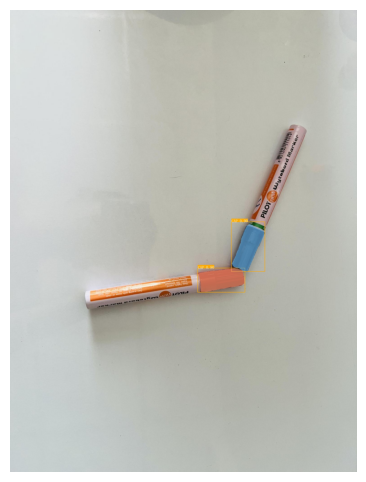

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('output/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg')

plt.figure(figsize=(6, 6))
plt.axis('off')
plt.imshow(img)
plt.show()

In [11]:
# !python tools/infer.py \
# -c configs/queryinst/queryinst_markers.yml \
# -o weights=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/queryinst_markers/best_model \
# -o use_gpu=True \
# --infer_dir=/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/ \
# --output_dir=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/queryinst_markers/infer_images/ \
# --draw_threshold=0.5 \
# --save_results=True

In [12]:
# import numpy as np
# import os
# import random
# import matplotlib.pyplot as plt
# import cv2
# # ---------------- CONFIG ----------------
# val_dir = "/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/queryinst_markers/infer_images/"

# # visualization layout
# N = 4
# cols = 4
# rows = int(np.ceil(N / cols))

# # random image selection
# all_imgs = [os.path.join(val_dir, f)
#             for f in os.listdir(val_dir)
#             if f.lower().endswith((".jpg", ".png", ".jpeg"))]

# sample_imgs = random.sample(all_imgs, N)

# plt.figure(figsize=(4 * cols, 4 * rows))

# for ii, image in enumerate(sample_imgs):
#     plt.subplot(rows, 4, ii+1)

#     img = cv2.imread(image)

#     plt.subplot(rows, cols, ii + 1)
#     plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
#     plt.axis("off")

# plt.tight_layout()
# plt.show()

In [3]:
import sys

# Add PaddleDetection to path
pd_det_path = '/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection'
sys.path.insert(0, pd_det_path)

from ppdet.core.workspace import load_config, merge_config
from ppdet.engine import Trainer

# 1. Load config and weights
config_path = 'configs/queryinst/queryinst_markers.yml'
cfg = load_config(config_path)
cfg.weights = '/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/queryinst_markers/best_model.pdparams'
cfg.use_gpu = True
image_file = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg'

# 2. Initialize Trainer
trainer = Trainer(cfg, mode='test')
trainer.load_weights(cfg.weights)

# 3. Run Inference
results = trainer.predict([image_file], draw_threshold=0.5)

print(results[0].keys())
print(results)

[05/22 19:07:31] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
[05/22 19:07:46] ppdet.utils.checkpoint INFO: Finish loading model weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/queryinst_markers/best_model.pdparams
loading annotations into memory...
Done (t=7.53s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


100%|██████████| 1/1 [00:02<00:00,  2.47s/it]


[05/22 19:07:57] ppdet.engine INFO: Detection bbox results save in output/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg
dict_keys(['bbox', 'bbox_num', 'mask', 'im_shape', 'scale_factor', 'im_id'])
[{'bbox': array([[1.00000000e+00, 9.02818143e-01, 9.79709045e+02, 9.39393677e+02,
        1.12830054e+03, 1.15846936e+03],
       [1.00000000e+00, 8.97099972e-01, 8.30781799e+02, 1.14483386e+03,
        1.04058545e+03, 1.25001501e+03],
       [1.00000000e+00, 1.88674673e-01, 9.78869385e+02, 9.43611633e+02,
        1.13051489e+03, 1.15956567e+03],
       [1.00000000e+00, 1.08345941e-01, 3.28386292e+02, 1.16783899e+03,
        8.46375183e+02, 1.32457263e+03],
       [1.00000000e+00, 8.15373436e-02, 9.78985046e+02, 9.39298340e+02,
        1.13213354e+03, 1.16040247e+03],
       [1.00000000e+00, 6.37392923e-02, 9.79489807e+02, 9.47681580e+02,
        1.12953882e+03, 1.16058484e+03],
       [1.00000000e+00, 5.91729283e-02, 8.33641357e+02, 1.14400439e+03,
       

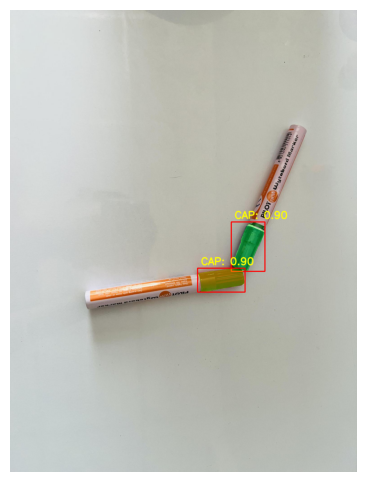

In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random
import os

# Class labels
CLASS_LABELS = ["", "CAP"]
PRED_COLORS = {1: (0, 255, 0)} # Green for CAP
CONF_THRESHOLD = 0.5

# Load the original image
img = cv2.imread(image_file)
H, W = img.shape[:2]
img_with_masks = img.copy()

res = results[0]

def draw_bbox_with_label(img, bbox, label, score, color=(0, 0, 255), thickness=3):
    xmin, ymin, xmax, ymax = map(int, bbox)
    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, thickness)
    cv2.putText(
        img, f"{label}: {score:.2f}", (xmin + 15, ymin - 15),
        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 255), 3, cv2.LINE_AA)

# Extract QueryInst explicit data types
bboxes_data = res['bbox']  # Shape: [Num_Objects, 6] -> [class_id, score, xmin, ymin, xmax, ymax]
masks = res['mask']        # Binary mask arrays mapped directly to indices
num_objects = res['bbox_num'][0]

# Loop through the valid detected objects
for i in range(num_objects):
    # Extract prediction values from the row matrix
    class_id = int(bboxes_data[i][0])
    score = float(bboxes_data[i][1])
    bbox = bboxes_data[i][2:6] # xmin, ymin, xmax, ymax

    if score < CONF_THRESHOLD:
        continue

    # Assign target labeling color
    color = PRED_COLORS.get(class_id, (0, 255, 0))

    # 1. Process Mask (QueryInst masks match image dimensions out-of-the-box)
    mask = masks[i]
    if mask.shape[:2] != (H, W):
        mask = cv2.resize(mask.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST)

    mask_bool = mask.astype(bool)

    # 2. Draw Translucent Colored Mask Overlay
    colored_mask = np.zeros_like(img, dtype=np.uint8)
    colored_mask[mask_bool] = color
    img_with_masks = cv2.addWeighted(img_with_masks, 1.0, colored_mask, 0.4, 0)

    # 3. Draw bounding box from the explicit 'bbox' data vector
    class_name = CLASS_LABELS[class_id] if class_id < len(CLASS_LABELS) else f"ID:{class_id}"
    draw_bbox_with_label(img_with_masks, bbox, class_name, score, color=(0, 0, 255))

# Display plot frame window
img_rgb = cv2.cvtColor(img_with_masks, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.axis('off')
plt.imshow(img_rgb)
plt.show()

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


100%|██████████| 1/1 [00:00<00:00,  1.73it/s]


[05/22 19:17:45] ppdet.engine INFO: Detection bbox results save in output/70E8E5CF-1E37-4B90-A67E-CD0125007B88_jpeg.rf.78956797972f7e1ec64ae1958911f775.jpg
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


100%|██████████| 1/1 [00:00<00:00,  1.94it/s]


[05/22 19:17:47] ppdet.engine INFO: Detection bbox results save in output/6A3A70A1-514E-42A5-8348-83D8CEC6DB50_jpeg.rf.033078e246bbc7fbfe1c49a7a7c101d3.jpg
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


100%|██████████| 1/1 [00:00<00:00,  1.23it/s]


[05/22 19:17:56] ppdet.engine INFO: Detection bbox results save in output/791B657F-ECFC-494E-9D29-19E4FD891119_jpeg.rf.021c12a68d599926e955a2b7b9ea32e4.jpg
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


100%|██████████| 1/1 [00:00<00:00,  1.65it/s]


[05/22 19:17:57] ppdet.engine INFO: Detection bbox results save in output/B497AD9D-A21B-4DC9-A05A-1B306E40D612_jpeg.rf.4d3f214dd42e1deee677eb9c6acff0ab.jpg


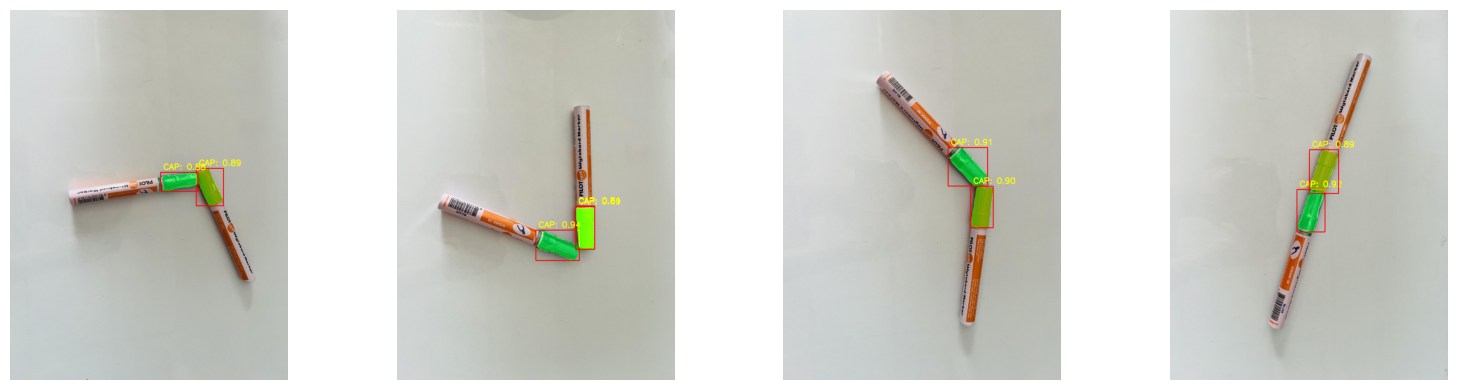

In [11]:
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/"

# Class labels
CLASS_LABELS = ["", "CAP"]
PRED_COLORS = {1: (0, 255, 0)} # Green for CAP
CONF_THRESHOLD = 0.5

# visualization layout
N = 4
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 4 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(1, 4, ii+1)

    img = cv2.imread(image)

    results = trainer.predict([image])

    H, W = img.shape[:2]
    img_with_masks = img.copy()

    res = results[0]

    bboxes_data = res['bbox']  # Shape: [Num_Objects, 6] -> [class_id, score, xmin, ymin, xmax, ymax]
    masks = res['mask']        # Binary mask arrays mapped directly to indices
    num_objects = res['bbox_num'][0]

    # Loop through the valid detected objects
    for i in range(num_objects):
        # Extract prediction values from the row matrix
        class_id = int(bboxes_data[i][0])
        score = float(bboxes_data[i][1])
        bbox = bboxes_data[i][2:6] # xmin, ymin, xmax, ymax

        if score < CONF_THRESHOLD:
            continue

        # Assign target labeling color
        color = PRED_COLORS.get(class_id, (0, 255, 0))

        # 1. Process Mask (QueryInst masks match image dimensions out-of-the-box)
        mask = masks[i]
        if mask.shape[:2] != (H, W):
            mask = cv2.resize(mask.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST)

        mask_bool = mask.astype(bool)

        # 2. Draw Translucent Colored Mask Overlay
        colored_mask = np.zeros_like(img, dtype=np.uint8)
        colored_mask[mask_bool] = color
        img_with_masks = cv2.addWeighted(img_with_masks, 1.0, colored_mask, 0.6, 0)

        # 3. Draw bounding box from the explicit 'bbox' data vector
        class_name = CLASS_LABELS[class_id] if class_id < len(CLASS_LABELS) else f"ID:{class_id}"
        draw_bbox_with_label(img_with_masks, bbox, class_name, score, color=(0, 0, 255))

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img_with_masks, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()